<a href="https://colab.research.google.com/github/adzetto/marine_analysis/blob/main/su-seviyesi/colab_baslat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/adzetto/marine_analysis/blob/main/su-seviyesi/colab_baslat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bozyazı deniz seviyesi analizi — Colab

Hocanın istediği çıktılar:

1. Ayıklanmış veriden **MSL**
2. **Gelgit bileşenleri** tablosu — ad, genlik [m], faz [derece]
   (Famagusta Tablo 2-2 biçiminde)
3. **Gelgit düzeyleri** tablosu — HAT, MHWS, MHHW, MHW, MHWN, MSL,
   MLWN, MLW, MLLW, MLWS, LAT [m +MSL] (Tablo 2-3 biçiminde)
4. **Gelgit dışı** su yükselmeleri — ortalama, dağılım ve PDF/CDF grafiği

Analiz dönemi makalenin Bozyazı penceresiyle aynı: **01.01.2010 –
13.03.2018**. (Makale 2009'da başlıyor ama portalda Bozyazı kaydı 2010
başında başlıyor; bitiş tarihi birebir aynı tutuldu.)

**Çalışma zamanını yüksek RAM'e alın.** 15 dakikalık çözünürlükte
312.000 nokta için UTide'ın tasarım matrisi birkaç GB istiyor.

`Çalışma zamanı → Çalışma zamanı türünü değiştir → Yüksek RAM`

## 1. Kurulum

Bu hücre tekrar tekrar çalıştırılabilir; her seferinde temiz klon alır.
(Önceki sürümde art arda çalıştırınca dizin kendi içine klonlanıp
çıktılar iç içe klasörlere dağılmıştı.)

In [1]:
%cd /content
!rm -rf /content/marine_analysis
!git clone -q https://github.com/adzetto/marine_analysis.git
%cd /content/marine_analysis/su-seviyesi
!pip install -q -r requirements.txt
!pwd

/content
/content/marine_analysis/su-seviyesi
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 9.3 MB/s eta 0:00:00
/content/marine_analysis/su-seviyesi


LaTeX isteğe bağlı — kurulmazsa figürler matplotlib'in kendi matematik
dizgisiyle üretilir, betikler bunu kendisi algılar.

In [2]:
!apt-get -qq update && apt-get -qq install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super > /dev/null
print('latex kuruldu')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
latex kuruldu


In [3]:
import psutil, os
gb = psutil.virtual_memory().total / 1e9
print(f'toplam RAM : {gb:.1f} GB   CPU: {os.cpu_count()} cekirdek')
if gb < 20:
    print('UYARI: yuksek RAM calisma zamanina gecmeniz onerilir.')

toplam RAM : 89.6 GB   CPU: 12 cekirdek


## 2. Veri

Veri depoyla geliyor. `tudes.harita.gov.tr` Türkiye dışındaki DNS
çözümleyicilerinden çözülmediği için indirme Colab'da çalışmaz.

In [4]:
from ortak import oku, kes, PAPER_BAS, PAPER_BIT
s = oku()
x = kes(s, PAPER_BAS, PAPER_BIT)
print(f'tum ayiklanmis seri : {len(s):,} kayit  '
      f'({s.index.min().date()} -> {s.index.max().date()})')
print(f'analiz penceresi    : {len(x):,} kayit  '
      f'({PAPER_BAS} -> {PAPER_BIT})')
print(f'MSL (bu pencerede)  : {x.mean():.4f} m  '
      f'[istasyonun yerel datumu]')

tum ayiklanmis seri : 568,677 kayit  (2010-01-01 -> 2026-07-31)
analiz penceresi    : 283,889 kayit  (2010-01-01 -> 2018-03-13)
MSL (bu pencerede)  : 1.4822 m  [istasyonun yerel datumu]


## 3. Ayıklama

Depodaki `bozyazi_temiz.dat.gz` zaten bu adımın çıktısı. Yeniden üretmek
isterseniz çalıştırın; `04` ayıklamanın doğru şeyi sildiğini sınar.

In [5]:
!python -u 03_veri_ayikla.py
!python -u 04_ayiklama_dogrula.py

AYIKLAMA
izgara   : 581,305 adim   dolu 565,482   bos 15,823
baslangic: min -371.149  max 775.551 m

  1) |x - medyan| > 2.0 m                          2,067 olcum
  2) 30 gun medyanindan > 0.8 m sapma              1,508 olcum
  3.1) kisa medyandan sapma > 0.100 m (robust sigma 0.0000)   4,610 olcum
  3.2) kisa medyandan sapma > 0.100 m (robust sigma 0.0000)     252 olcum
  4) ayni deger 12+ kez ust uste (takilma)         6,607 olcum
--------------------------------------------------------------------------
  TOPLAM ATILAN                                   15,044 olcum  (ham verinin %2.660'u)
  KALAN                                          550,438 olcum

ayiklama sonrasi: min 0.850  max 2.343  ort 1.5151  std 0.1555 m

1 gunden kisa bosluklar dolduruldu: +18,239 olcum
analize giren toplam              : 568,677

ORTALAMA DENIZ SEVIYESI (MSL)
  tum kayit  2010-2026           MSL = 1.5149 m   (n=568,677, std 0.1558)
  temiz on yil  2010-2019        MSL = 1.4813 m   (n=347,057, std 0.147

## 4. Gelgit bileşenleri  (hocanın 2. isteği)

UTide harmonik çözümü + yayımlanmış Bozyazı değerleriyle karşılaştırma.
Ağır adım bu.

In [6]:
!python -u 05_harmonik_analiz.py

MAKALE PENCERESI  (2010-01-01-2018-03-13)   n = 283,889 olcum (8.10 yil)
SNR > 2 olan 39 bilesen (68 bilesen cozuldu). En buyuk 14:
  bilesen    genlik cm   +- cm   faz deg         SNR
  M2             9.614   0.044     241.4      46,831
  SA             9.393   0.568     237.2         273
  S2             5.603   0.044     256.7      15,907
  SSA            4.193   0.564     264.1          55
  K1             2.447   0.038     284.0       4,229
  O1             1.834   0.038     264.0       2,376
  K2             1.639   0.044     252.9       1,361
  N2             1.581   0.044     243.7       1,266
  P1             0.889   0.038     301.1         559
  S1             0.748   0.038     280.6         395
  H1             0.325   0.044     189.4          54
  L2             0.321   0.044     245.7          52
  NU2            0.290   0.044     245.1          43
  Q1             0.287   0.038     249.7          58

  Form faktoru F = 0.281   Enerji faktoru E = 0.083   ->  karisik, agirl

## 5. Gelgit düzeyleri  (hocanın 3. isteği)

In [7]:
!python -u 06_gelgit_seviyeleri.py

GELGIT DUZEYLERI - Bozyazi   (bilesenler 2010-01-01-2018-03-13)
gozlenen MSL (ayiklanmis veri) = 1.4822 m (istasyon yerel datumu)
ongoru: 2010-01-01 -> 2028-12-31  (999,324 adim, 10 dk)
bulunan yuksek su : 13,398   alcak su : 13,399
bahar gelgiti     : 470 olay   olusum gelgiti : 470 olay
ortalama gelgit genligi (HHW-LLW) = 25.0 cm

GELGIT DUZEYLERI  (MSL'e gore, m)
  duzey  aciklama                                 ampirik    formul   datum m
----------------------------------------------------------------------------
  HAT    En yuksek astronomik gelgit               +0.501         -     1.983
  MHWS   Bahar gelgiti ortalama yuksek su          +0.155    +0.152     1.637
  MHHW   Ortalama yuksek-yuksek su                 +0.130         -     1.612
  MHW    Ortalama yuksek su                        +0.108         -     1.590
  MHWN   Olusum gelgiti ortalama yuksek su         +0.039    +0.040     1.521
  MSL    Ortalama deniz seviyesi                   +0.000    +0.000     1.482
  MLWN  

## 6. Gelgit dışı su yükselmeleri  (hocanın 4. isteği)

Ortalama, standart sapma, yüzdelikler ve PDF/CDF grafiği.

In [8]:
!python -u 07_non_tidal.py

LaTeX dizgisi: acik
MAKALE PENCERESI  (2010-01-01-2018-03-13)   n = 283,889
  ortalama       : -0.0000 cm   <-- tanimi geregi ~0
  standart sapma : 9.01 cm   <-- dagilimi temsil eden buyukluk
  en dusuk / en yuksek : -39.2 / +50.5 cm
  azami aralik   : 89.7 cm
  TD (gelgit baskinligi) : 1.321
  yuzdelikler (cm):
    %0.1=-31.7  %1=-21.8  %5=-14.6  %10=-11.0  %25=-5.5  %50=-0.0  %75=+5.3  %90=+11.0  %95=+15.0  %99=+23.4  %99.9=+34.1
    figur: 01_nontidal_pdf_cdf_makale_penceresi  (kutu 2 cm, tepe PDF 0.101)
    figur: 02_nontidal_zaman_serisi_makale_penceresi


DOGRULAMA: Ozturk & Yuksel (2023) Tablo 3, Bozyazi
  buyukluk                      makale     bizim      fark
----------------------------------------------------------------------------
  azami aralik (cm)             129.00     89.71    -39.29
  standart sapma (cm)            10.43      9.01     -1.42
  TD                              1.06      1.32     +0.26
  ortalama (cm)                   0.00     -0.00     -0.00

tablolar

## 7. Deniz seviyesi değişimi  (hocanın 1. cümlesi)

Bozyazı'daki yıllar arası değişimin bölgesel mi istasyona özgü mü
olduğunu komşu istasyonlarla (Taşucu, Erdemli, Antalya) karşılaştırarak
sınar.

Komşu istasyonların ham verisi depoda değil (her biri ~33 MB), bu yüzden
Colab'da bu betik atlanır. Sonucu `tables/06_istasyon_yillik_sapma.csv`
ve `figures/03_istasyon_karsilastirma.png` olarak depoda hazır.

,yil,bozyazi,tasucu,erdemli,antalya
0,2010,6.03,4.76,2.44,4.66
1,2011,0.89,-0.62,-2.98,-0.73
2,2012,-0.99,3.48,-1.44,0.88
3,2013,-2.77,-1.93,0.61,3.61
4,2014,-4.28,-6.72,-2.59,1.67
5,2015,-7.73,-7.55,-1.98,2.45
6,2016,-4.10,-5.43,-0.14,-0.10
7,2017,-11.11,-9.37,-4.51,-7.31
8,2018,-3.54,NaN,1.39,NaN
9,2019,-4.72,3.72,-0.64,-1.17


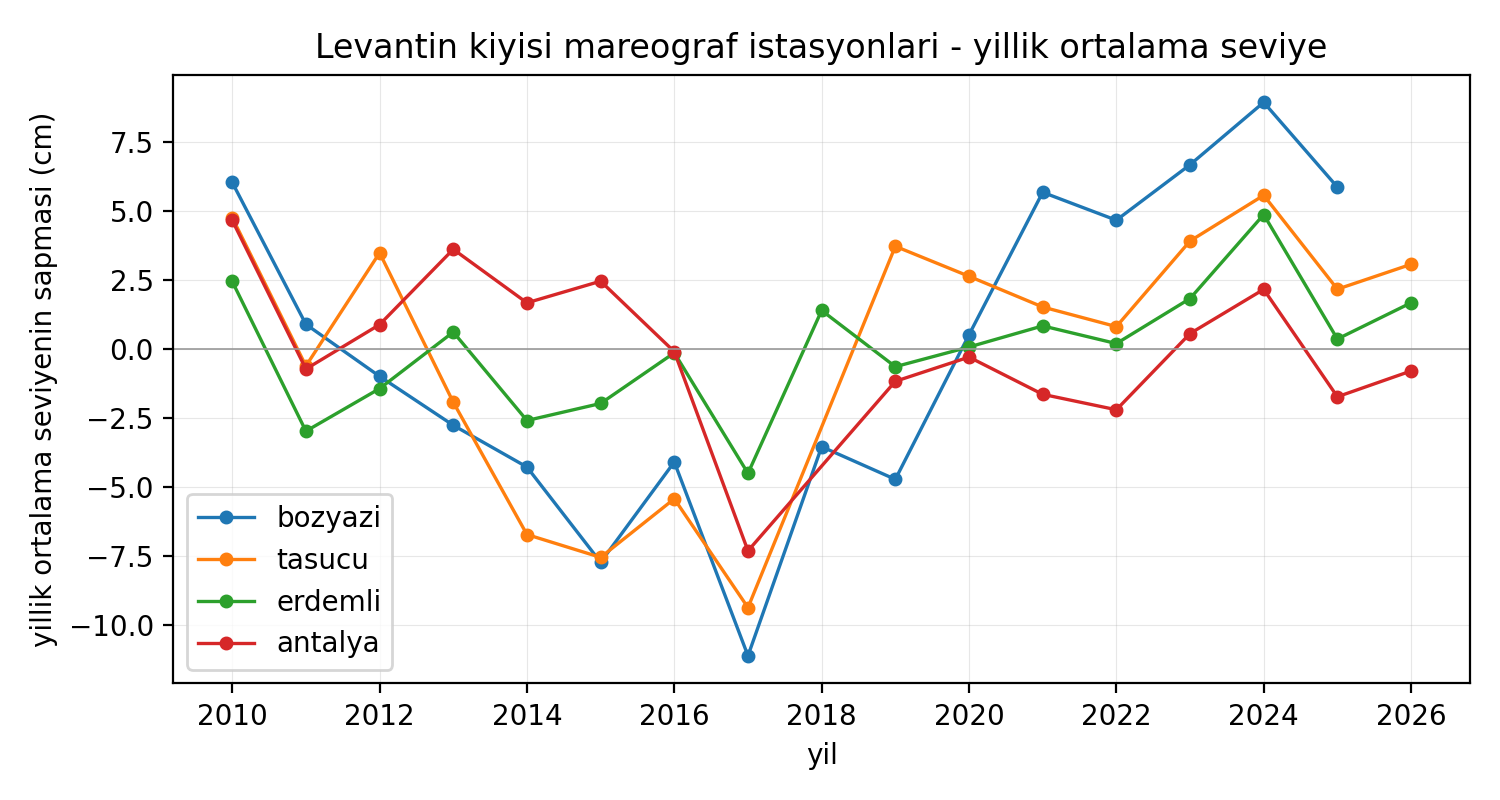

In [9]:
import pandas as pd
from IPython.display import display, Image
display(pd.read_csv('tables/06_istasyon_yillik_sapma.csv'))
display(Image('figures/03_istasyon_karsilastirma.png'))

## 8. Sonuçları göster

tables/01_gelgit_bilesenleri_makale_penceresi.csv


,bilesen,genlik_cm,genlik_hata_cm,faz_derece,SNR
0,M2,9.6143,0.0444,241.41,46831.4
1,SA,9.3928,0.5681,237.15,273.4
2,S2,5.6032,0.0444,256.68,15907.2
3,SSA,4.1927,0.5638,264.06,55.3
4,K1,2.4474,0.0376,283.97,4228.8
5,O1,1.8343,0.0376,263.99,2375.5
6,K2,1.6389,0.0444,252.91,1361.0
7,N2,1.5808,0.0444,243.65,1266.0
8,P1,0.8895,0.0376,301.06,558.6
9,S1,0.7478,0.0376,280.58,394.8


tables/02_gelgit_duzeyleri.csv


,duzey,aciklama,su_seviyesi_m_MSL,formul_m_MSL,istasyon_datumu_m
0,HAT,En yuksek astronomik gelgit,0.5011,NaN,1.9833
1,MHWS,Bahar gelgiti ortalama yuksek su,0.1551,0.1522,1.6373
2,MHHW,Ortalama yuksek-yuksek su,0.1300,NaN,1.6121
3,MHW,Ortalama yuksek su,0.1078,NaN,1.5900
4,MHWN,Olusum gelgiti ortalama yuksek su,0.0388,0.0401,1.5210
5,MSL,Ortalama deniz seviyesi,0.0000,0.0000,1.4822
6,MLWN,Olusum gelgiti ortalama alcak su,-0.0462,-0.0401,1.4360
7,MLW,Ortalama alcak su,-0.1078,NaN,1.3744
8,MLLW,Ortalama alcak-alcak su,-0.1199,NaN,1.3623
9,MLWS,Bahar gelgiti ortalama alcak su,-0.1565,-0.1522,1.3257


tables/03_nontidal_ozet.csv


...

tables/05_donem_ozeti.csv


,donem,baslangic,bitis,form_faktoru_F,enerji_faktoru_E,trend_mm_yil
0,makale penceresi,2010-01-01,2018-03-13,0.2814,0.083,-18.697


tables/06_istasyon_yillik_sapma.csv


,yil,bozyazi,tasucu,erdemli,antalya
0,2010,6.03,4.76,2.44,4.66
1,2011,0.89,-0.62,-2.98,-0.73
2,2012,-0.99,3.48,-1.44,0.88
3,2013,-2.77,-1.93,0.61,3.61
4,2014,-4.28,-6.72,-2.59,1.67
5,2015,-7.73,-7.55,-1.98,2.45
6,2016,-4.10,-5.43,-0.14,-0.10
7,2017,-11.11,-9.37,-4.51,-7.31
8,2018,-3.54,NaN,1.39,NaN
9,2019,-4.72,3.72,-0.64,-1.17


figures/00_dogrulama_eylul2025.png


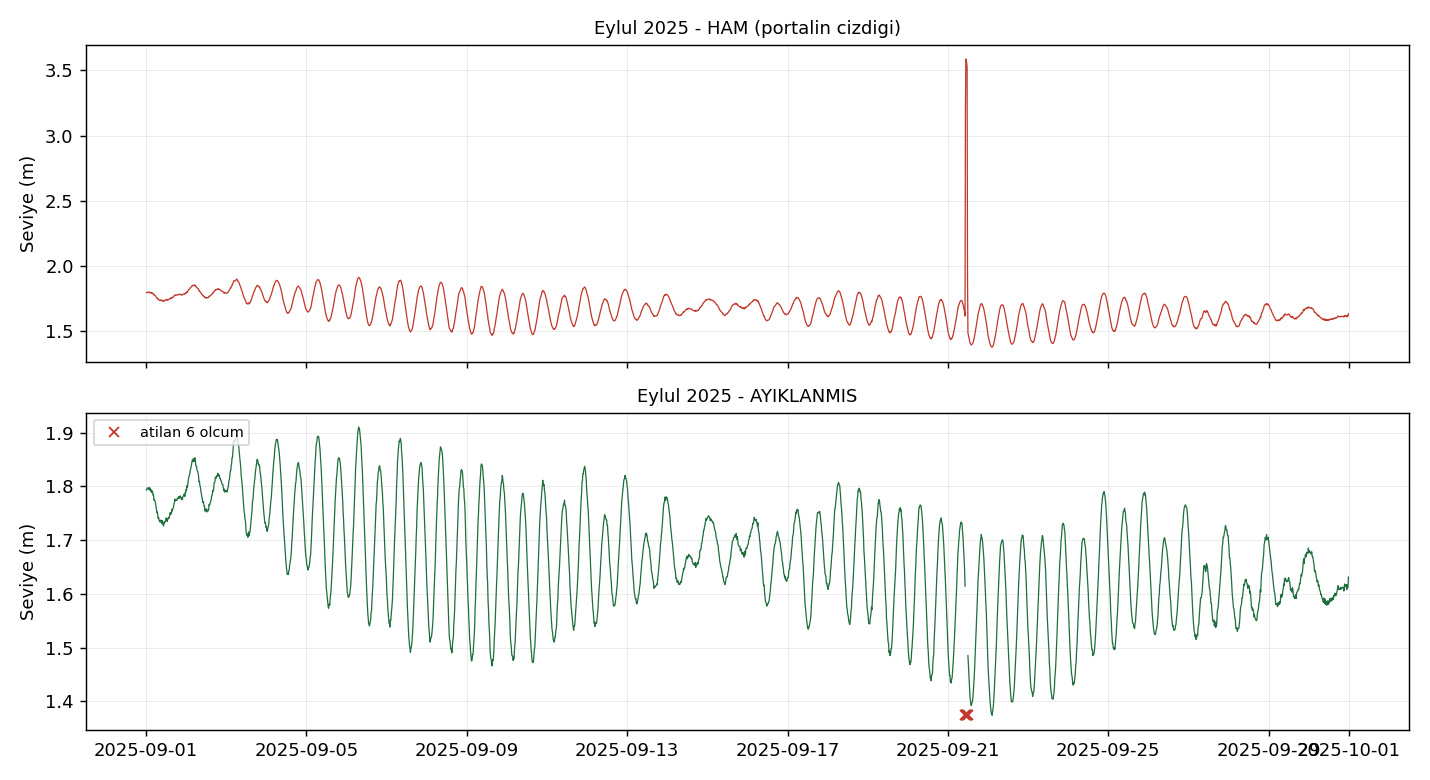

figures/00_dogrulama_nisan2024.png


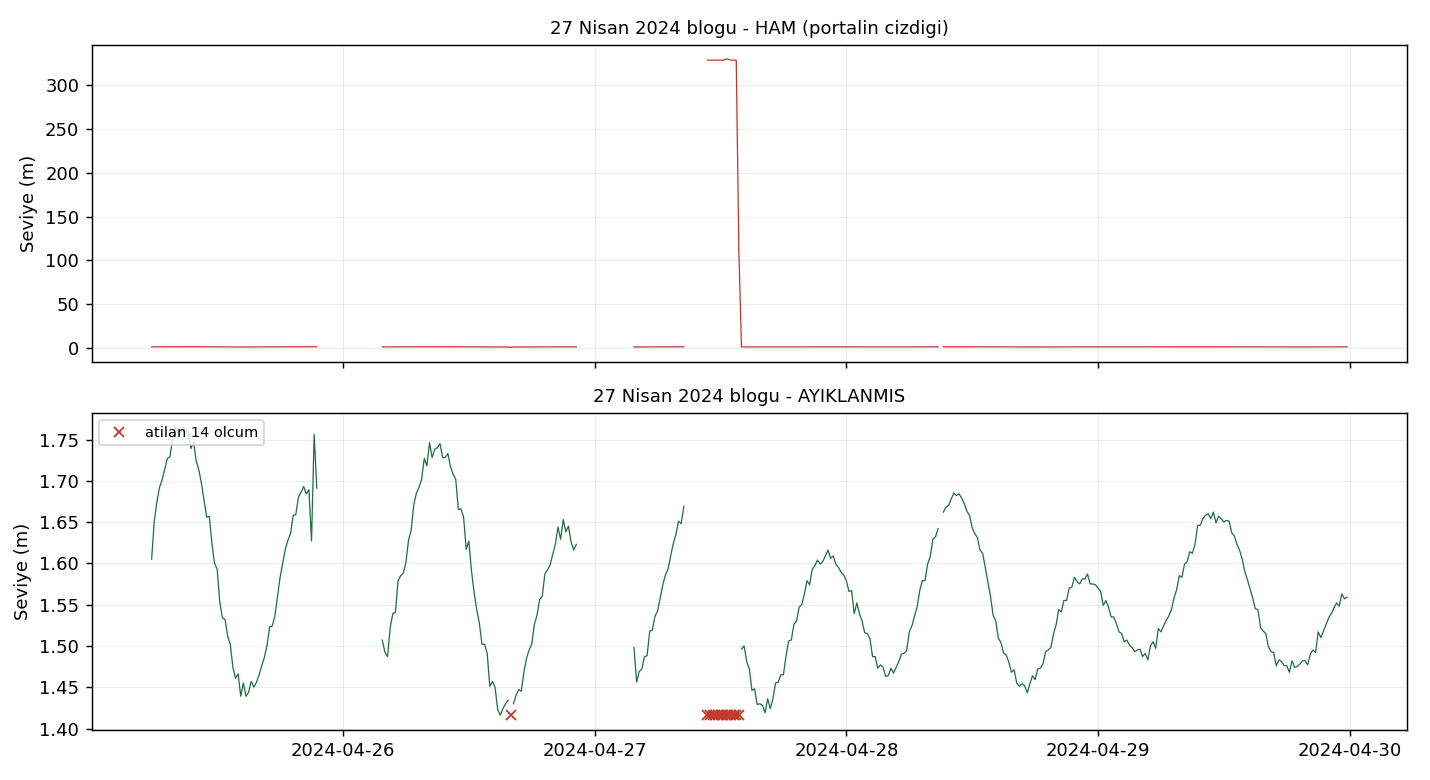

figures/00_dogrulama_temmuz2025.png


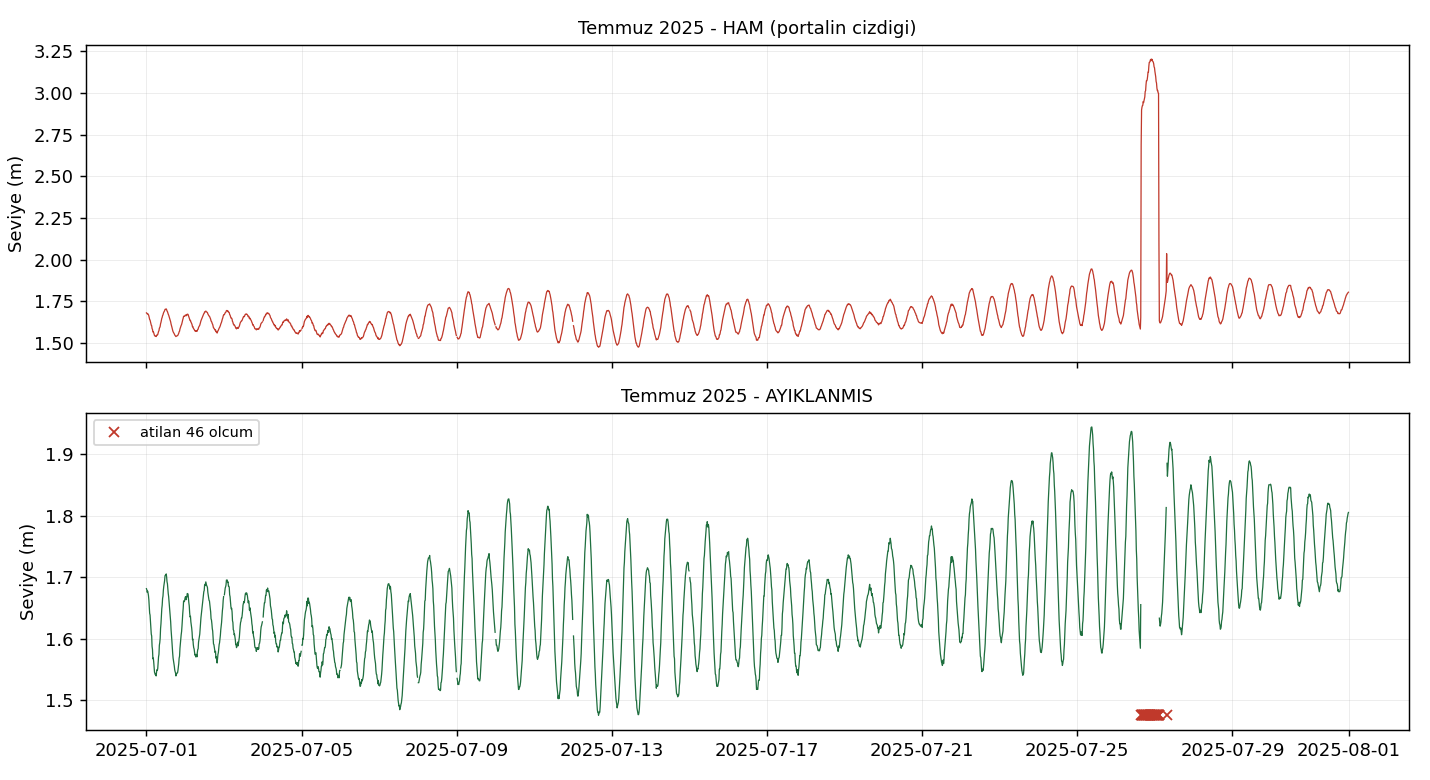

figures/00_tani_kesikler.png


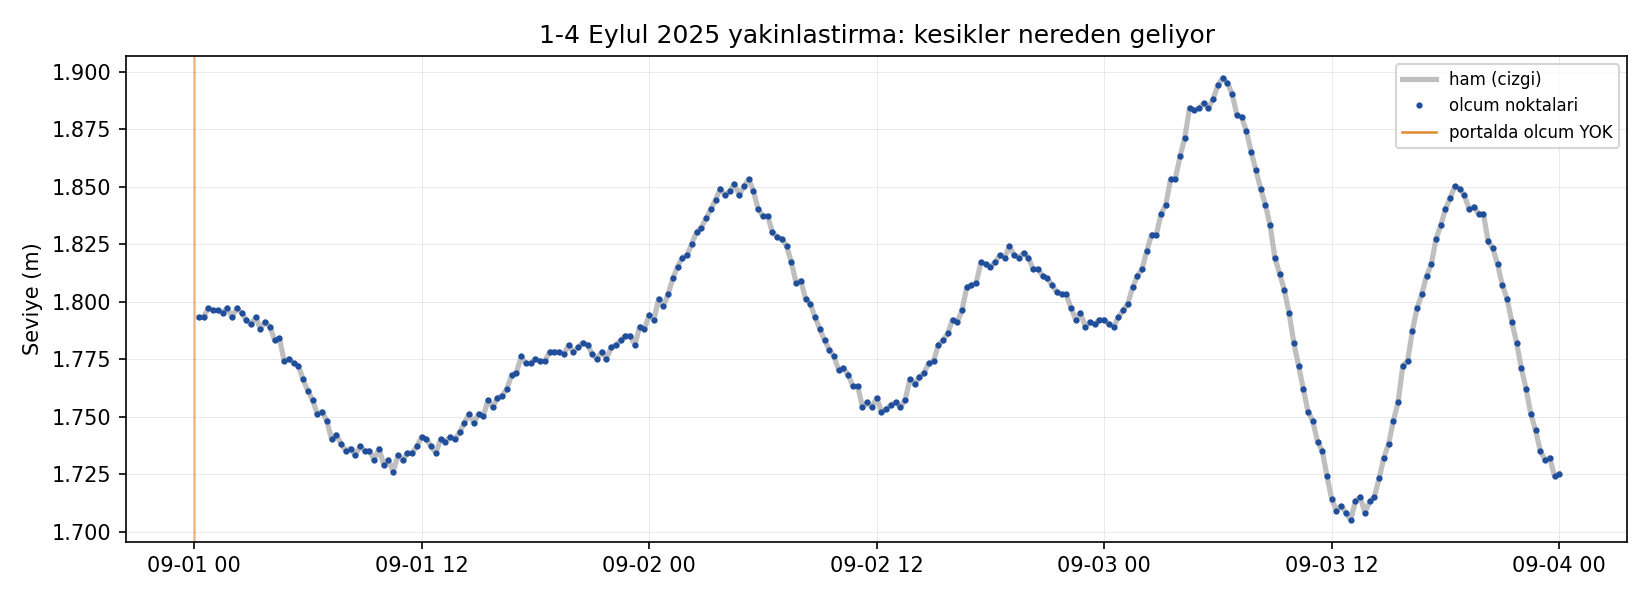

figures/01_nontidal_pdf_cdf_makale_penceresi.png


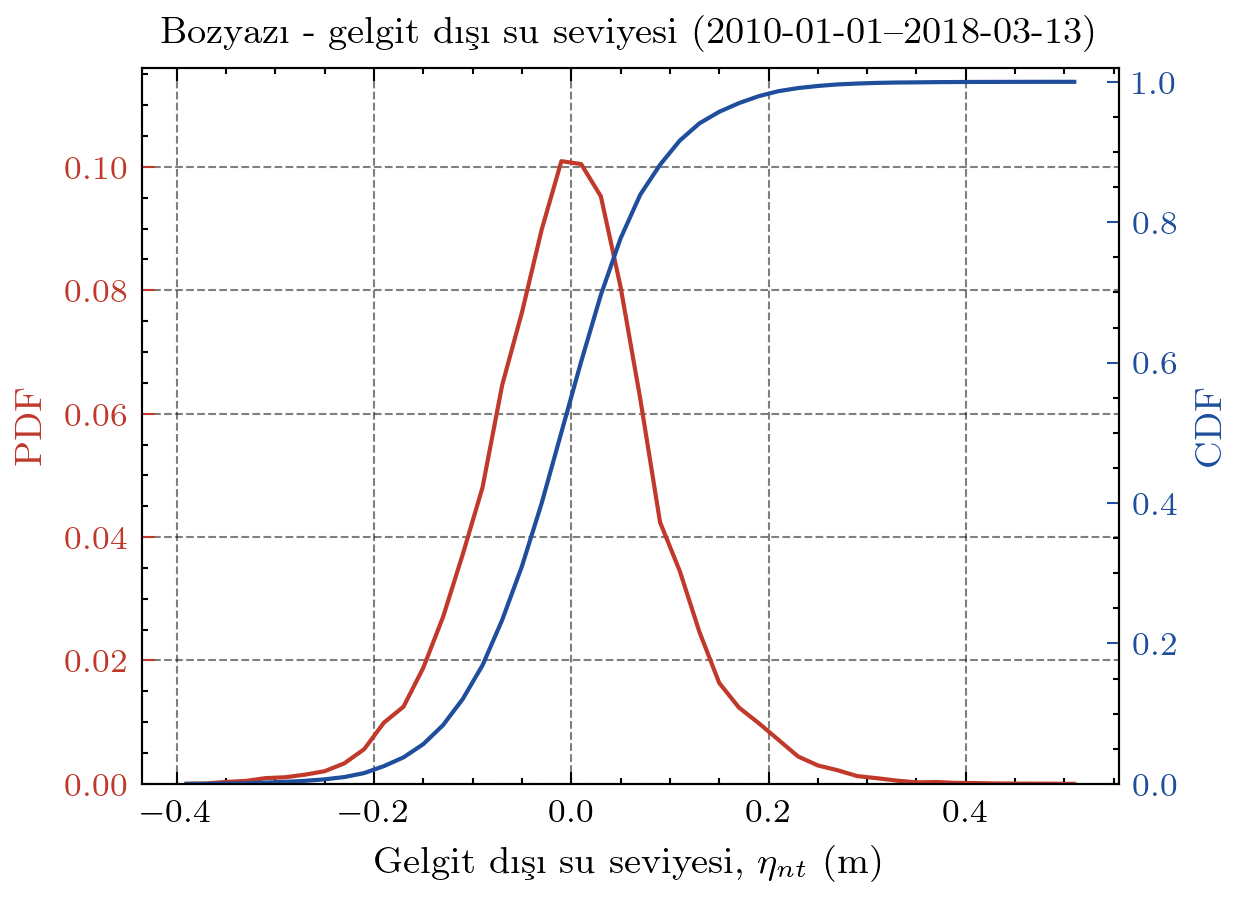

figures/02_nontidal_zaman_serisi_makale_penceresi.png


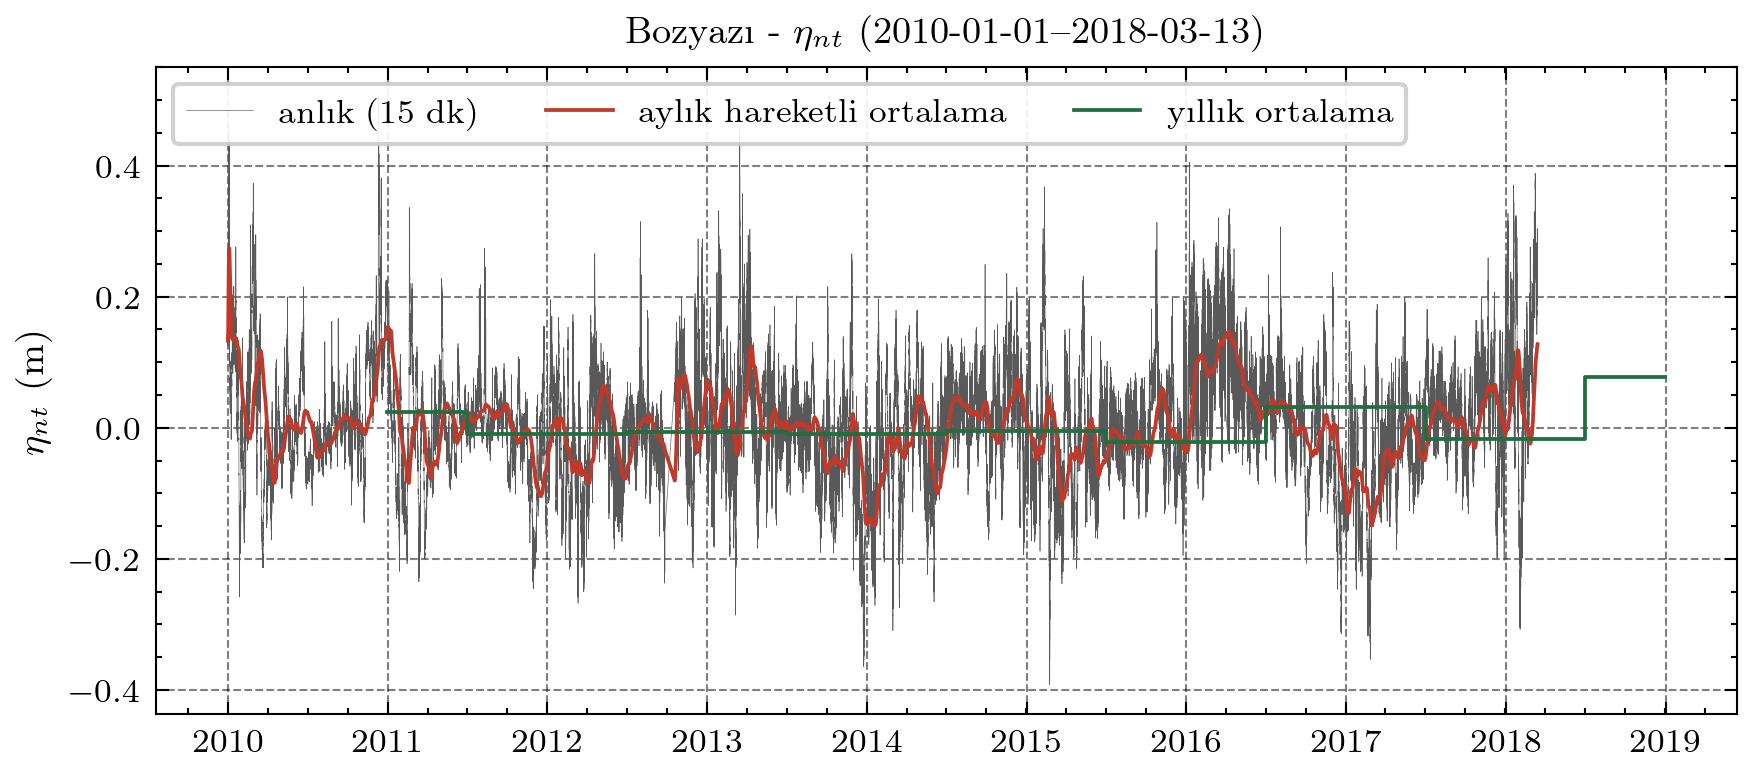

figures/03_istasyon_karsilastirma.png


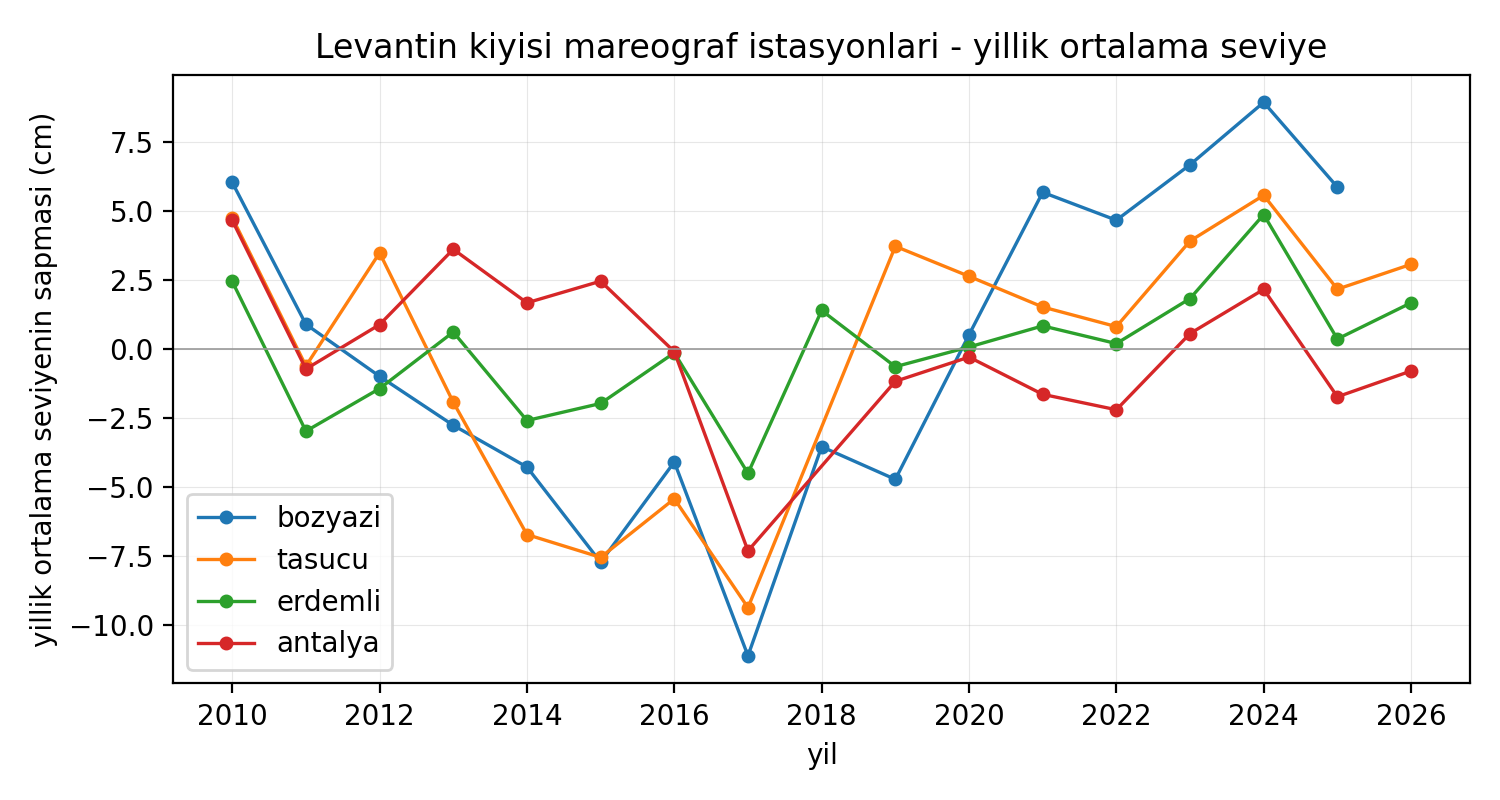

In [10]:
import pandas as pd, glob
from IPython.display import display, Image

for f in sorted(glob.glob('tables/*.csv')):
    print('=' * 70); print(f); print('=' * 70)
    display(pd.read_csv(f))

for f in sorted(glob.glob('figures/*.png')):
    print(f)
    display(Image(f))

## 9. Çıktıları indir

In [11]:
%cd /content/marine_analysis/su-seviyesi
!zip -qr /content/bozyazi_sonuclar.zip tables figures data
from google.colab import files
files.download('/content/bozyazi_sonuclar.zip')

/content/marine_analysis/su-seviyesi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>